About the Dataset:
Each entry in this dataset consists of a text segment representing a Twitter message and a corresponding label indicating the predominant emotion conveyed. The emotions are classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5). Whether you're interested in sentiment analysis, emotion classification, or text mining, this dataset provides a rich foundation for exploring the nuanced emotional landscape within the realm of social media.

In [1]:
# kaggle commands to load the dataset
# !pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -dnelgiriyewithana/emotions

Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/emotions
License(s): other
100% 15.7M/15.7M [00:02<00:00, 7.99MB/s]



In [2]:
# unzipping the kaggle data
import zipfile
with zipfile.ZipFile('emotions.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [155]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.6 MB/s eta 0:00:00


In [156]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re

# machine learing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# deep learnings
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

# nltk and spacy
import nltk
# nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

import spacy

# word2vec
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
# word cloud
from wordcloud import WordCloud


In [4]:
# data loading and initial inference
df = pd.read_csv('/content/data/text.csv')
df.shape

(416809, 3)

In [5]:
df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [6]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  416809 non-null  int64 
 1   text        416809 non-null  object
 2   label       416809 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 9.5+ MB


In [7]:
# any null values
df.isna().sum()

,0
Unnamed: 0,0
text,0
label,0


In [8]:
# any duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# what is the distribution of each class in label
df['label'].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


In [10]:
# now lets remove the unamed col use less feature
df.drop(columns=['Unnamed: 0'], inplace=True)

In [18]:
df.sample(5)

,text,label
90791,i think i was wary of not feeling too nostalgi...,2
76587,i feel sympathetic toward her position being i...,2
386563,i hate feeling so low and confused and unsure ...,0
234266,i am feeling the need to write another humorou...,1
114102,i feel very distracted by the tinsel and trees...,3


In [41]:
# text cleaning and preprocessing

def basic_cleaning(text):
    text = re.sub(r'http\S+', '', text) # link removal
    text = re.sub(r'[^a-zA-Z\s]', '', text) # removes unwanted characters
    # alpha numeric characters
    text = re.sub(r'\w*\d\w*', '', text)
    # removing htmls
    text = re.sub(r'<.*?>', '', text)
    # lowercasing
    text = text.lower()
    return text

df['text'] = df['text'].apply(basic_cleaning)

In [20]:
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [28]:
# slight advance cleaining
from spacy.lang.en.stop_words import STOP_WORDS

print(set(STOP_WORDS))
print(len(set(STOP_WORDS)))

{'fifteen', 'there', 'last', 'behind', 'yourselves', 'whoever', 'it', 'top', 'herein', 'nevertheless', 'how', "'d", 'n‘t', 'hereby', 'really', 'next', 'sometime', 'becomes', 'whereas', 'anyway', 'either', 'just', 'more', 'seem', '‘s', 'become', 'full', 'nor', 'empty', 'rather', 'something', 'into', 'name', 'along', 'yet', 'even', 'should', 'whereafter', 'being', 'upon', 'call', 'mine', 'too', 'beforehand', 'although', 'them', 'before', "'m", 'further', 'against', 'me', 'say', 'the', 'beside', 'thereby', 'moreover', 'almost', 'back', 'us', 'did', 'a', 'anyhow', 'very', 'therein', '’ve', 'here', 'out', 'whereby', '’d', 'might', '’re', 'i', 'you', 'make', 'neither', 'any', 'what', 'give', 'none', 'least', 'most', 'that', 'all', 'someone', 'everywhere', 'please', "'ve", 'few', 'made', 'became', 'perhaps', 'toward', 'and', 'do', 'one', 'than', 'another', 'her', 'two', 'less', 'whenever', 'himself', 'from', 'meanwhile', 'show', 'ever', 'have', 'amount', 'must', 'or', 'where', 'elsewhere', 'i

In [40]:
# trying the tokenisation
nlp = spacy.load('en_core_web_sm')
doc = nlp(df['text'][2])
tokens = [token.text for token in doc]
print(tokens)

# stopword removall
tokens = [token for token in tokens if token not in STOP_WORDS]
print(tokens)

# stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(token) for token in tokens]
print(stemmed_tokens)

# lemma
import nltk
# nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
print(lemmatized_tokens)

['i', 'gave', 'up', 'my', 'internship', 'with', 'the', 'dmrg', 'and', 'am', 'feeling', 'distraught']
['gave', 'internship', 'dmrg', 'feeling', 'distraught']
['gave', 'internship', 'dmrg', 'feel', 'distraught']
['gave', 'internship', 'dmrg', 'feeling', 'distraught']


In [39]:
df['text'][2]

'i gave up my internship with the dmrg and am feeling distraught'

In [86]:
def fully_cleaned(text):
  # tokenisation
  doc = nlp(text)
  tokens = [token.text for token in doc]
  # stop word removals
  tokens = [token for token in tokens if token not in STOP_WORDS]
  # stemming and lemma
  tokens = [lemmatizer.lemmatize(token) for token in tokens]

  # tokens = [token for token in tokens if len(token) >= 2]  # after watching the reuslt
  # tokens = set(tokens)

  return ' '.join(tokens)

fully_cleaned(df['text'][0])


'helpless feel hearted heavy'

In [52]:
# since it it taking a logn time i would take random 10k text for each category
new_df = pd.DataFrame()
for i in range(6):
  new_df = pd.concat([new_df, df[df['label'] == i].sample(10000,random_state=2)])

In [53]:
new_df['label'].value_counts()

,count
label,
0,10000
1,10000
2,10000
3,10000
4,10000
5,10000


In [54]:
new_df.head()

,text,label
120877,i must also confess that i feel very sorry for...,0
82197,i were very fortunate to not feel the effects ...,0
147983,i wrong to feel unimportant,0
284073,i am i feel that i am doomed to have a space t...,0
122426,i want him to feel what its like to be hated,0


In [55]:
new_df.reset_index(drop=True, inplace=True)

In [56]:
new_df['text'] = new_df['text'].apply(basic_cleaning)

In [57]:
new_df['clean_text'] = new_df['text'].apply(fully_cleaned)

In [66]:
new_df.sample(10)

,text,label,clean_text
3345,i feel like i have so much ugly pain says witc...,0,feel like ugly pain say witch baby dream
51509,i feel amazed by him i havent thought about wh...,5,feel amazed nt thought feel way long time
11890,i ask is the feeling around the blogs appears ...,1,ask feeling blog appears range disgust joyful ...
11191,i was the new kid on the block and it wasn t a...,1,new kid block wasn t feeling welcomed
58327,i am feeling overwhelmed i dont feel hopeless ...,5,feeling overwhelmed nt feel hopeless cycle fru...
24615,i am typing this now into my computer about ho...,2,typing computer hour later feeling loving joyf...
46814,i get involved into a tale of good verses evil...,4,involved tale good verse evil want feel afraid...
9997,i feel lousy and would prefer to do research b...,0,feel lousy prefer research reading novel watch...
10037,i feel so thankful for all that ive experience...,1,feel thankful ve experienced company embarked
44906,i am certain they will do a fine humane job of...,4,certain fine humane job harvesting feel strange


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

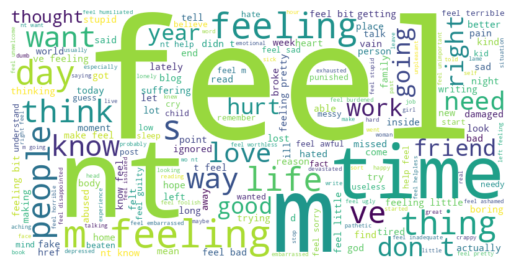

In [63]:
# creating word clouds for each label / class
from wordcloud import WordCloud
sad_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 0]['clean_text']))
plt.imshow(sad_cloud, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

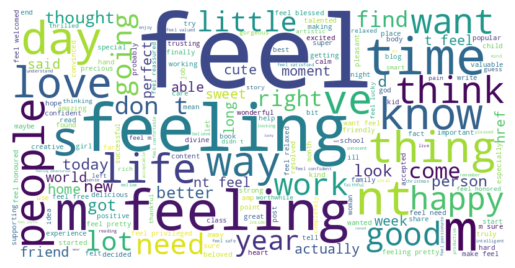

In [64]:
joy_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 1]['clean_text']))
plt.imshow(joy_cloud, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

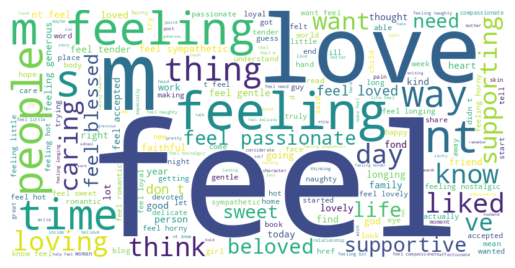

In [68]:
love_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 2]['clean_text']))
plt.imshow(love_cloud, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

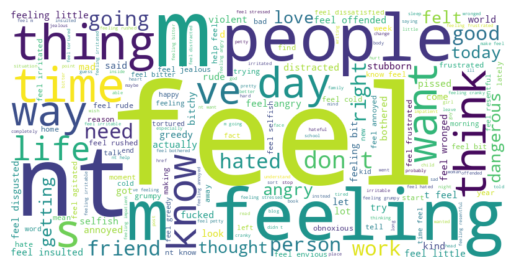

In [69]:
anger_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 3]['clean_text']))
plt.imshow(anger_cloud, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

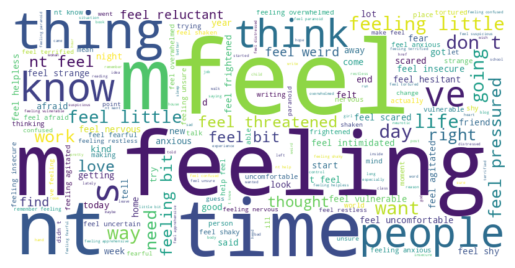

In [70]:
fear_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 4]['clean_text']))
plt.imshow(fear_cloud, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

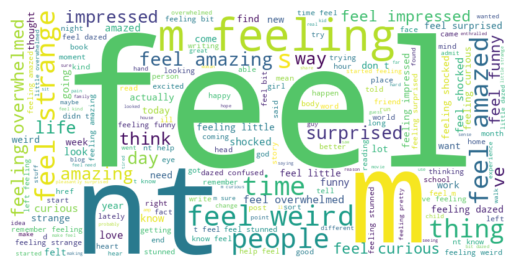

In [71]:
surprise_cloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(new_df[new_df['label'] == 5]['clean_text']))
plt.imshow(surprise_cloud, interpolation='bilinear')
plt.axis('off')

In [74]:
# removing the raw text feature
new_df.drop(columns=['text'], inplace=True)

In [75]:
# some feature extraction and then interpretation
# first lets create seoarate df for each category
sad_df = new_df[new_df['label'] == 0]
joy_df = new_df[new_df['label'] == 1]
love_df = new_df[new_df['label'] == 2]
anger_df = new_df[new_df['label'] == 3]
fear_df = new_df[new_df['label'] == 4]
surprise_df = new_df[new_df['label'] ==5]

In [76]:
sad_df

,label,clean_text
0,0,confess feel sorry
1,0,fortunate feel effect altitude sickness dull h...
2,0,wrong feel unimportant
3,0,feel doomed space entirely filled bogus advert...
4,0,want feel like hated
...,...,...
9995,0,feel like ignored
9996,0,flip flop purse relief feel stupid nice dress ...
9997,0,feel lousy prefer research reading novel watch...
9998,0,started listening heart pound leave feeling in...


In [92]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [93]:
# max and min length of word in this data subset
arr = []
for text in sad_df['clean_text']:
  # spliting using spac word tokeinsation
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('the maximum is ' , max(arr) , 'and text is ', sad_df['clean_text'][arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', sad_df['clean_text'][arr.index(min(arr))])

the maximum is  39 and text is  feel stressed ti friday night want good want good night faackin want good good night got ta feeling wooooo hooooo tonight s gon na good night tonight s gon na good night tonight s gon na good good night
the minimum is  1 and text is  feel


In [95]:
# same for others
arr = []
for text in joy_df['clean_text']:
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('for joy')
print('the maximum is ' , max(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for text in love_df['clean_text']:
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('for love')
print('the maximum is ' , max(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for text in anger_df['clean_text']:
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('for anger')
print('the maximum is ' , max(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for text in fear_df['clean_text']:
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('for fear')
print('the maximum is ' , max(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for text in surprise_df['clean_text']:
  tokens = word_tokenize(text)
  arr.append(len(tokens))

print('for surprise')
print('the maximum is ' , max(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(min(arr))])

for joy
the maximum is  33 and text is  feel honored shortlist congratulate wish nominee best tonight award thank age scotland kindness div class intro style background color fff color font family trebuchet m helvetica bitstream vera sans sans serif font size
the minimum is  0 and text is  
for love
the maximum is  47 and text is  muzica aleasa si ritmul succesiunii imaginilor dau slideshowurilor un feeling un pic prea romantic pentru un serial care este de fapt unul de actiune yvonne canta pe coarda pe care ne o dorim cu totii toate s o facem sa rezoneze cand este vorba sik nu asa
the minimum is  2 and text is  feel horny
for anger
the maximum is  66 and text is  day waiting bus bus stop getting bus prepared exact coin pay bus fair got bus coin box meant collect bus fair thought paid wanted inside bus driver called asked impolite way coin stuck opening box seen paying nt stack coin box understand driver kept questioning feel angry inserted dollar coin box away later found forgotten co

In [97]:
# count of letter in whole sentence
arr = []
for sent in sad_df['clean_text']:
  arr.append(len(sent))

print('for sad')
print('the maximum is ' , max(arr) , 'and text is ', sad_df['clean_text'][arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', sad_df['clean_text'][arr.index(min(arr))])

# same for others
arr = []
for sent in joy_df['clean_text']:
  arr.append(len(sent))

print('for joy')
print('the maximum is ' , max(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in love_df['clean_text']:
  arr.append(len(sent))

print('for love')
print('the maximum is ' , max(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in anger_df['clean_text']:
  arr.append(len(sent))

print('for anger')
print('the maximum is ' , max(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in fear_df['clean_text']:
  arr.append(len(sent))

print('for fear')
print('the maximum is ' , max(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in surprise_df['clean_text']:
  arr.append(len(sent))

print('for surprise')
print('the maximum is ' , max(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(min(arr))])

for sad
the maximum is  268 and text is  living working condition home unbearable live room flat family discord caused change family moved family stayed drifted away fianct fact family flat found struggle life fianct stay grief sorrow took large proportion wanted commit suicide instead threw cause irritation
the minimum is  3 and text is  bad
for joy
the maximum is  227 and text is  literally feel progress generation slave freedman sharecropper member talented tenth supporter tuskegee machine civil right activist freedom rider black panther blackwatch movement amp native tongue family erased annals history
the minimum is  0 and text is  
for love
the maximum is  255 and text is  muzica aleasa si ritmul succesiunii imaginilor dau slideshowurilor un feeling un pic prea romantic pentru un serial care este de fapt unul de actiune yvonne canta pe coarda pe care ne o dorim cu totii toate s o facem sa rezoneze cand este vorba sik nu asa
the minimum is  8 and text is  feel hot
for anger
the ma

In [101]:
# ooo we have some empty text strings
new_df['clean_text'].isna().sum() # shows nothing as we have empty strings

np.int64(0)

In [103]:
new_df[new_df['clean_text'] == '']

,label,clean_text
11073,1,
31276,3,
39996,3,
40790,4,
44627,4,
45027,4,


In [119]:
new_df = new_df[new_df['clean_text'] != '']

In [120]:
new_df.shape

(59994, 2)

In [121]:
new_df['label'].value_counts()

,count
label,
0,10000
2,10000
5,10000
1,9999
3,9998
4,9997


In [123]:
# after

sad_df = new_df[new_df['label'] == 0]
joy_df = new_df[new_df['label'] == 1]
love_df = new_df[new_df['label'] == 2]
anger_df = new_df[new_df['label'] == 3]
fear_df = new_df[new_df['label'] == 4]
surprise_df = new_df[new_df['label'] ==5]

# count of letter in whole sentence
arr = []
for sent in sad_df['clean_text']:
  arr.append(len(sent))

print('for sad')
print('the maximum is ' , max(arr) , 'and text is ', sad_df['clean_text'][arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', sad_df['clean_text'][arr.index(min(arr))])

# same for others
arr = []
for sent in joy_df['clean_text']:
  arr.append(len(sent))

print('for joy')
print('the maximum is ' , max(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', joy_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in love_df['clean_text']:
  arr.append(len(sent))

print('for love')
print('the maximum is ' , max(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', love_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in anger_df['clean_text']:
  arr.append(len(sent))

print('for anger')
print('the maximum is ' , max(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', anger_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in fear_df['clean_text']:
  arr.append(len(sent))

print('for fear')
print('the maximum is ' , max(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', fear_df['clean_text'].iloc[arr.index(min(arr))])

arr = []
for sent in surprise_df['clean_text']:
  arr.append(len(sent))

print('for surprise')
print('the maximum is ' , max(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(max(arr))])
print('the minimum is ' , min(arr) , 'and text is ', surprise_df['clean_text'].iloc[arr.index(min(arr))])

for sad
the maximum is  268 and text is  living working condition home unbearable live room flat family discord caused change family moved family stayed drifted away fianct fact family flat found struggle life fianct stay grief sorrow took large proportion wanted commit suicide instead threw cause irritation
the minimum is  3 and text is  bad
for joy
the maximum is  227 and text is  literally feel progress generation slave freedman sharecropper member talented tenth supporter tuskegee machine civil right activist freedom rider black panther blackwatch movement amp native tongue family erased annals history
the minimum is  5 and text is  night
for love
the maximum is  255 and text is  muzica aleasa si ritmul succesiunii imaginilor dau slideshowurilor un feeling un pic prea romantic pentru un serial care este de fapt unul de actiune yvonne canta pe coarda pe care ne o dorim cu totii toate s o facem sa rezoneze cand este vorba sik nu asa
the minimum is  8 and text is  feel hot
for anger
t

In [124]:
# for now lets save first
new_df.to_csv('cleaned_csv')

In [126]:
# lets find the unique words for each class
sad_words = set(' '.join(sad_df['clean_text']).split())
joy_words = set(' '.join(joy_df['clean_text']).split())
love_words = set(' '.join(love_df['clean_text']).split())
anger_words = set(' '.join(anger_df['clean_text']).split())
fear_words = set(' '.join(fear_df['clean_text']).split())
surprise_words = set(' '.join(surprise_df['clean_text']).split())

print('number of unique words in sad', len(sad_words) ,list(sad_words))
print('number of unique words in joy', len(joy_words),list(joy_words))
print('number of unique words in love', len(love_words),list(love_words))
print('number of unique words in anger', len(anger_words),list(anger_words))
print('number of unique words in fear', len(fear_words),list(fear_words))
print('number of unique words in surprise', len(surprise_words),list(surprise_words))

number of unique words in sad 9560 ['foundation', 'opinionated', 'discontinuing', 'nauseous', 'italy', 'despite', 'monday', 'suffered', 'couch', 'hidden', 'lot', 'implying', 'frankly', 'middle', 'disorder', 'daisy', 'ftp', 'legacy', 'bowl', 'intense', 'nit', 'escalator', 'motorcycle', 've', 'scary', 'albeit', 'hoping', 'matched', 'shakey', 'edwardian', 'conveying', 'pretentious', 'paralysis', 'wopas', 'cuisine', 'sabbath', 'glorious', 'relieved', 'legitimate', 'nantucket', 'pointless', 'plan', 'being', 'tournament', 'distinguishing', 'call', 'wraith', 'restlessness', 'occurs', 'realised', 'xxx', 'yous', 'acquiescing', 'remarkable', 'kneading', 'snuggled', 'messed', 'preference', 'stink', 'anne', 'suck', 'captured', 'spectacularly', 'equation', 'flash', 'complementarity', 'everyday', 'later', 'abortion', 'trash', 'ladder', 'subject', 'spender', 'priest', 'beginning', 'goldeneye', 'house', 'p', 'smarter', 'face', 'dealt', 'suggests', 'reddit', 'neil', 'scheduled', 'dallas', 'include', 'c

In [128]:
# list of common words
common_words = sad_words.intersection(joy_words).intersection(love_words).intersection(anger_words).intersection(fear_words).intersection(surprise_words)
print(len(common_words), list(common_words))

3101 ['opposite', 'pet', 'method', 'savior', 'flying', 'apparently', 'crazy', 'notion', 'hearing', 'nauseous', 'despite', 'instrument', 'monday', 'suffered', 'couch', 'release', 'lot', 'section', 'hopefully', 'relationship', 'photograph', 'frankly', 'middle', 'bowl', 'intense', 'isn', 'worthy', 'partner', 'motorcycle', 've', 'washing', 'information', 'progress', 'health', 'quit', 'pie', 'albeit', 'weren', 'hoping', 'easily', 'finishing', 'construction', 'announcement', 'weekly', 'understanding', 'guess', 'google', 'alive', 'involved', 'perfect', 'relieved', 'beloved', 'dreamed', 'prison', 'resulted', 'plan', 'being', 'call', 'daughter', 'occurs', 'ignoring', 'realised', 'immediate', 'fourth', 'asleep', 'womens', 'messed', 'ok', 'match', 'passed', 'span', 'body', 'cell', 'greater', 'suck', 'copy', 'equation', 'mentally', 'flash', 'wrong', 'cuz', 'bare', 'review', 'perfectly', 'signed', 'english', 'everyday', 'medication', 'later', 'pressure', 'based', 'trash', 'happening', 'subject', 'p

In [130]:
# feature creation for just try how ml model will become

new_df['text_len'] = new_df['clean_text'].apply(len)
new_df['word_count'] = new_df['clean_text'].apply(lambda x: len(x.split()))
new_df['unique_word_count'] = new_df['clean_text'].apply(lambda x: len(set(x.split())))
new_df['avg_words'] = new_df['text_len'] / new_df['word_count']
new_df['unique_words_ratio'] = new_df['unique_word_count'] / new_df['word_count']

/tmp/ipykernel_661/3744384846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_len'] = new_df['clean_text'].apply(len)
/tmp/ipykernel_661/3744384846.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['word_count'] = new_df['clean_text'].apply(lambda x: len(x.split()))
/tmp/ipykernel_661/3744384846.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [132]:
first_model_df = new_df.drop(columns=['clean_text'])

In [135]:
# shuffling the data
first_model_df = first_model_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [140]:
first_model_df

,label,text_len,word_count,unique_word_count,avg_words,unique_words_ratio
0,2,35,6,6,5.833333,1.000000
1,0,124,21,18,5.904762,0.857143
2,5,41,6,6,6.833333,1.000000
3,0,32,5,5,6.400000,1.000000
4,4,46,8,8,5.750000,1.000000
...,...,...,...,...,...,...
59989,5,51,10,10,5.100000,1.000000
59990,3,25,4,4,6.250000,1.000000
59991,0,22,3,3,7.333333,1.000000
59992,1,78,12,12,6.500000,1.000000


In [138]:
# lets see after applying the simple models of ml how are the results so we will have the knowledge how to move forward
X = first_model_df.drop(columns=['label'])
y = first_model_df['label']

<Axes: xlabel='text_len', ylabel='Count'>

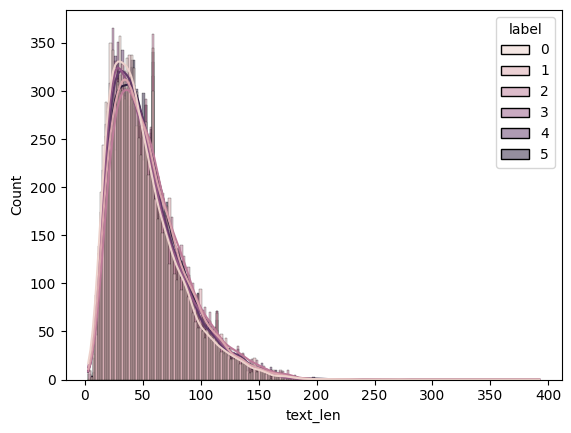

In [141]:
# little visulisation
sns.histplot(data=first_model_df, x='text_len', hue='label', kde=True)

<Axes: xlabel='word_count', ylabel='Count'>

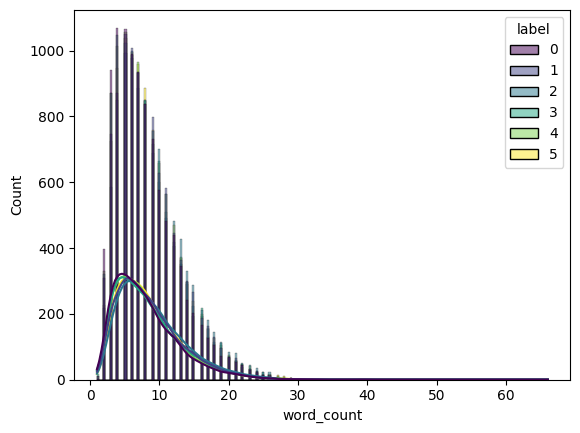

In [143]:
sns.histplot(data=first_model_df, x='word_count', hue='label', kde=True, palette='viridis')

<Axes: xlabel='unique_word_count', ylabel='Count'>

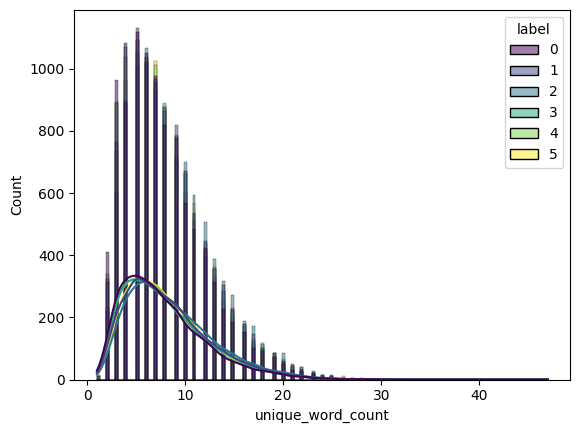

In [144]:
sns.histplot(data=first_model_df, x='unique_word_count', hue='label', kde=True, palette='viridis')

<Axes: xlabel='avg_words', ylabel='Count'>

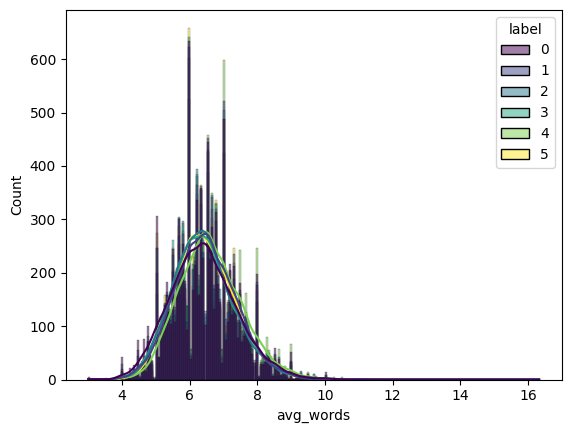

In [145]:
sns.histplot(data=first_model_df, x='avg_words', hue='label', kde=True, palette='viridis')

<Axes: xlabel='unique_words_ratio', ylabel='Count'>

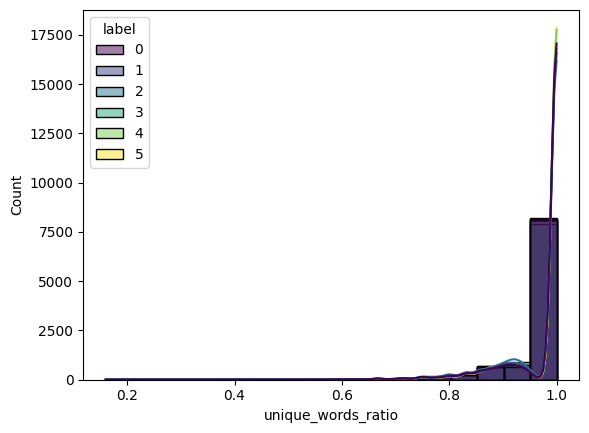

In [146]:
sns.histplot(data=first_model_df, x='unique_words_ratio', hue='label', kde=True, palette='viridis')

In [ ]:
# some features are almost same ! lets see what else we could do

In [139]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

Accuracy: 0.17876489707475623
              precision    recall  f1-score   support

           0       0.18      0.18      0.18      2010
           1       0.16      0.13      0.14      2007
           2       0.19      0.17      0.18      1957
           3       0.17      0.18      0.17      1964
           4       0.20      0.21      0.20      2077
           5       0.17      0.21      0.19      1984

    accuracy                           0.18     11999
   macro avg       0.18      0.18      0.18     11999
weighted avg       0.18      0.18      0.18     11999



In [ ]:
# ohh only 17  well these featrues where not sufficiant also we didnt applied any standarisation

In [151]:
# lets try the bow and ngrams
# ngram + bow + naive bayes
bow_ngram = new_df[['clean_text', 'label']]

X_train, X_test, y_train, y_test = train_test_split(bow_ngram['clean_text'], bow_ngram['label'], test_size=0.2, random_state=42)

vectorizer_bow = CountVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

In [152]:
# TF-IDF + N-grams
vectorizer_tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

In [158]:
# Word2Vec
sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_mean_vector(words, model, vector_size=100):
    vec = np.zeros(vector_size)
    count = 0
    for word in words:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    return vec / count if count != 0 else vec

X_train_w2v = np.array([get_mean_vector(text.split(), w2v_model) for text in X_train])
X_test_w2v = np.array([get_mean_vector(text.split(), w2v_model) for text in X_test])

In [164]:
from sklearn.naive_bayes import MultinomialNB , GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , f1_score
from sklearn.svm import LinearSVC

In [167]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name, feature_name, save_path=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred, target_names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], output_dict=True)
    print(f"\n{model_name} with {feature_name}:")
    print(f"  Accuracy: {acc:.4f}, F1 (weighted): {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']))
    if save_path:
        joblib.dump(model, save_path)
    return acc, f1, report

In [162]:
# Define models for count-based features
count_models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [165]:
# Define models for dense features (GaussianNB works with dense)
dense_models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [168]:
import os
import joblib

OUTPUT_DIR = '/content/output_models/'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Storage for results
results = {}

# Train count-based models (use BoW as representative)
for name, model in count_models.items():
    acc, f1, _ = train_and_evaluate(model, X_train_bow, X_test_bow, y_train, y_test,
                                    name, 'BoW+N-grams', f'{OUTPUT_DIR}/{name.lower().replace(" ", "_")}_bow.pkl')
    results[f"{name} (BoW)"] = {'Accuracy': acc, 'F1': f1}

# Also evaluate TF-IDF (just for comparison, but we save only BoW)
for name, model in count_models.items():
    acc, f1, _ = train_and_evaluate(model, X_train_tfidf, X_test_tfidf, y_train, y_test,
                                    name, 'TF-IDF+N-grams', None)
    results[f"{name} (TF-IDF)"] = {'Accuracy': acc, 'F1': f1}

# Train dense models with Word2Vec
for name, model in dense_models.items():
    acc, f1, _ = train_and_evaluate(model, X_train_w2v, X_test_w2v, y_train, y_test,
                                    name, 'Word2Vec', f'{OUTPUT_DIR}/{name.lower().replace(" ", "_")}_w2v.pkl')
    results[f"{name} (W2V)"] = {'Accuracy': acc, 'F1': f1}

# Save vectorizers and Word2Vec
joblib.dump(vectorizer_bow, f'{OUTPUT_DIR}/vectorizer_bow.pkl')
joblib.dump(vectorizer_tfidf, f'{OUTPUT_DIR}/vectorizer_tfidf.pkl')
w2v_model.save(f'{OUTPUT_DIR}/word2vec_model.bin')


Naive Bayes with BoW+N-grams:
  Accuracy: 0.9057, F1 (weighted): 0.9054
              precision    recall  f1-score   support

     sadness       0.94      0.89      0.92      2004
         joy       0.91      0.86      0.88      1963
        love       0.89      0.95      0.92      1980
       anger       0.91      0.91      0.91      2022
        fear       0.90      0.86      0.88      2013
    surprise       0.89      0.96      0.92      2017

    accuracy                           0.91     11999
   macro avg       0.91      0.91      0.91     11999
weighted avg       0.91      0.91      0.91     11999


Logistic Regression with BoW+N-grams:
  Accuracy: 0.9133, F1 (weighted): 0.9132
              precision    recall  f1-score   support

     sadness       0.95      0.91      0.93      2004
         joy       0.92      0.89      0.91      1963
        love       0.92      0.95      0.93      1980
       anger       0.92      0.92      0.92      2022
        fear       0.88      0.8

In [170]:
# final summary tabel
summary_df = pd.DataFrame.from_dict(results, orient='index')
summary_df.index.name = 'Model and Features'
print(summary_df.sort_values(by='F1', ascending=False))

                              Accuracy        F1
Model and Features                              
Logistic Regression (TF-IDF)  0.921577  0.921311
SVM (TF-IDF)                  0.918160  0.917978
Logistic Regression (BoW)     0.913326  0.913192
SVM (BoW)                     0.907492  0.907405
Naive Bayes (TF-IDF)          0.907076  0.906825
Naive Bayes (BoW)             0.905742  0.905420
Random Forest (TF-IDF)        0.904409  0.904188
Random Forest (BoW)           0.899825  0.899594
SVM (W2V)                     0.550046  0.537904
Logistic Regression (W2V)     0.497958  0.491255
Random Forest (W2V)           0.433869  0.427772
Naive Bayes (W2V)             0.281523  0.268382


In [ ]:
# ml models are performing way fine !

In [178]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [179]:
# lets try other ensemble models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [185]:
def train_beast_models(X_train, y_train, X_test, y_test):
    ensemble_models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'), # Changed to 'SAMME'
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42),
        'LightGBM': LGBMClassifier(n_estimators=100, random_state=42),
        'CatBoost': CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)
    }
    best_models = {}
    for name, model in ensemble_models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        best_models[name] = {'Accuracy': acc, 'F1': f1}
    return best_models

In [186]:
from sklearn.metrics import accuracy_score, f1_score
models = train_beast_models(X_train_tfidf, y_train, X_test_tfidf, y_test)
print("Ensemble Model Results with TF-IDF features:")
for name, metrics in models.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.4f}, F1 = {metrics['F1']:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.159718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 102017
[LightGBM] [Info] Number of data points in the train set: 47995, number of used features: 3264
[LightGBM] [Info] Start training from score -1.792155
[LightGBM] [Info] Start training from score -1.787165
[LightGBM] [Info] Start training from score -1.789158
[LightGBM] [Info] Start training from score -1.794660
[LightGBM] [Info] Start training from score -1.793657
[LightGBM] [Info] Start training from score -1.793783


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble Model Results with TF-IDF features:
Random Forest: Accuracy = 0.9044, F1 = 0.9042
Gradient Boosting: Accuracy = 0.8957, F1 = 0.8956
AdaBoost: Accuracy = 0.2496, F1 = 0.1713
XGBoost: Accuracy = 0.9158, F1 = 0.9155
LightGBM: Accuracy = 0.9208, F1 = 0.9206
CatBoost: Accuracy = 0.9019, F1 = 0.9018


In [ ]:
# our base models are way fine !